<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/07_Introduction_to_Statistics_in_Python/04_Correlation_and_Experimental_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. Correlation and Experimental Design

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/07_Introduction_to_Statistics_in_Python/Dataset/world_happiness.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
world_happiness = pd.read_csv(url)

# Print the head of the homelessness data
print(world_happiness.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_GDP.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
gdp = pd.read_csv(url)

# Print the head of the homelessness data
print(gdp.head())

   Unnamed: 0      country  social_support  freedom  corruption  generosity  \
0           1      Finland             2.0      5.0         4.0        47.0   
1           2      Denmark             4.0      6.0         3.0        22.0   
2           3       Norway             3.0      3.0         8.0        11.0   
3           4      Iceland             1.0      7.0        45.0         3.0   
4           5  Netherlands            15.0     19.0        12.0         7.0   

   gdp_per_cap  life_exp  happiness_score  
0        42400      81.8              155  
1        48300      81.0              154  
2        66300      82.6              153  
3        47900      83.0              152  
4        50500      81.8              151  
    Country Name Country Code     Indicator Name  Year           GDP
0          China          CHN  GDP (current US$)  2010  6.087160e+12
1        Germany          DEU  GDP (current US$)  2010  3.417090e+12
2          Japan          JPN  GDP (current US$)  2010

### Correlation

**Relationships between variables**  
In this chapter, you'll be working with a dataset world_happiness containing results from the 2019 World Happiness Report. The report scores various countries based on how happy people in that country are. It also ranks each country on various societal aspects such as social support, freedom, corruption, and others. The dataset also includes the GDP per capita and life expectancy for each country.

In this exercise, you'll examine the relationship between a country's life expectancy (life_exp) and happiness score (happiness_score) both visually and quantitatively. seaborn as sns, matplotlib.pyplot as plt, and pandas as pd are loaded and world_happiness is available.

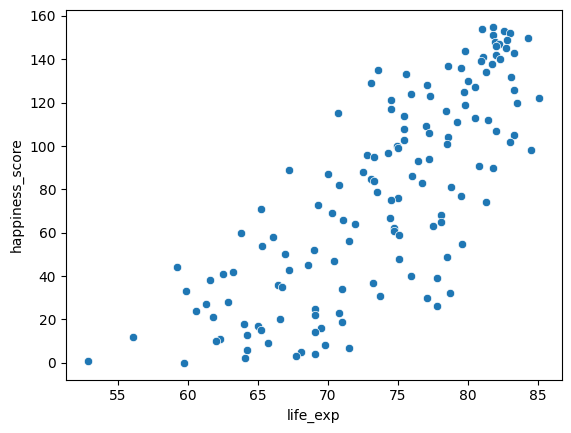

In [3]:
# Create a scatterplot of happiness_score vs. life_exp and show
sns.scatterplot(y='happiness_score', x='life_exp', data=world_happiness)

# Show plot
plt.show()

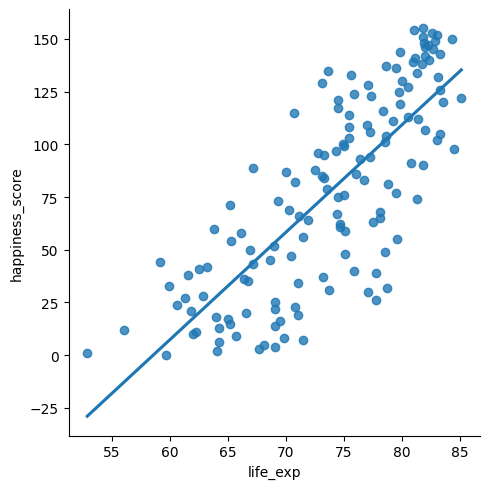

In [4]:
# Create scatterplot of happiness_score vs life_exp with trendline
sns.lmplot(y='happiness_score', x='life_exp', data=world_happiness, ci=None)

# Show plot
plt.show()

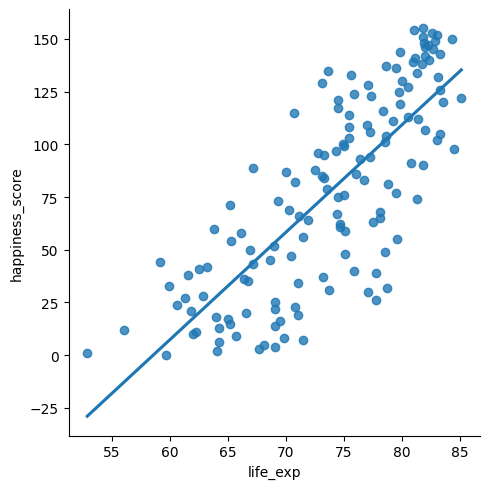

0.7802249053272062


In [5]:
# Create scatterplot of happiness_score vs life_exp with trendline
sns.lmplot(x='life_exp', y='happiness_score', data=world_happiness, ci=None)

# Show plot
plt.show()

# Correlation between life_exp and happiness_score
cor = world_happiness['life_exp'].corr(world_happiness['happiness_score'])

print(cor)

# Vibrant visualizations! Scatterplots with trendlines are a great way to verify that a relationship between two variables is indeed linear.

-----

### Correlation caveats

**What can't correlation measure?**  
While the correlation coefficient is a convenient way to quantify the strength of a relationship between two variables, it's far from perfect. In this exercise, you'll explore one of the caveats of the correlation coefficient by examining the relationship between a country's GDP per capita (gdp_per_cap) and happiness score.

pandas as pd, matplotlib.pyplot as plt, and seaborn as sns are imported, and world_happiness is loaded.

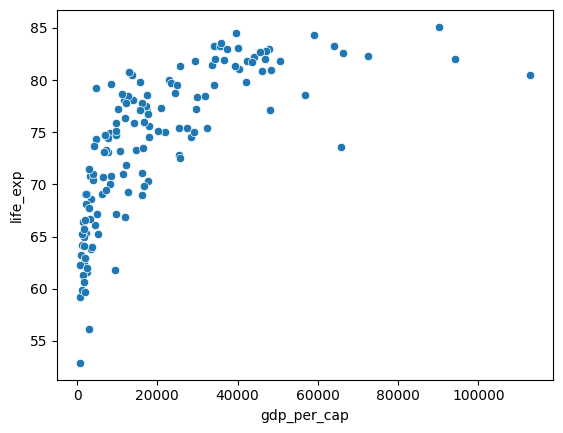

0.7019547642148012


In [6]:
# Scatterplot of gdp_per_cap and life_exp
sns.scatterplot(x='gdp_per_cap', y='life_exp', data=world_happiness)

# Show plot
plt.show()

# Correlation between gdp_per_cap and life_exp
cor = world_happiness['gdp_per_cap'].corr(world_happiness['life_exp'])

print(cor)

# The correlation coefficient can't account for any relationships that aren't linear, regardless of strength.

**Transforming variables**  
When variables have skewed distributions, they often require a transformation in order to form a linear relationship with another variable so that correlation can be computed. In this exercise, you'll perform a transformation yourself.

pandas as pd, numpy as np, matplotlib.pyplot as plt, and seaborn as sns are imported, and world_happiness is loaded.

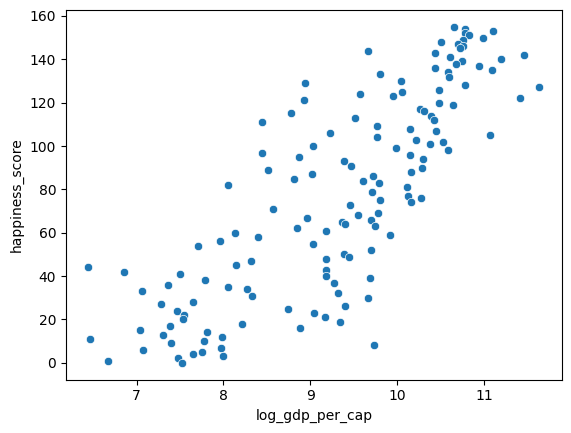

0.8043146004918289


In [8]:
# Create log_gdp_per_cap column
world_happiness['log_gdp_per_cap'] = np.log(world_happiness['gdp_per_cap'])

# Scatterplot of happiness_score vs. log_gdp_per_cap
sns.scatterplot(y='happiness_score', x='log_gdp_per_cap', data=world_happiness)
plt.show()

# Calculate correlation
cor = world_happiness['happiness_score'].corr(world_happiness['log_gdp_per_cap'])
print(cor)

# Terrific transforming! The relationship between GDP per capita and happiness became more linear by applying a log transformation.
# Log transformations are great to use on variables with a skewed distribution, such as GDP.

**Does sugar improve happiness?**  
A new column has been added to world_happiness called grams_sugar_per_day, which contains the average amount of sugar eaten per person per day in each country. In this exercise, you'll examine the effect of a country's average sugar consumption on its happiness score.

In [10]:
# Scatterplot of grams_sugar_per_day and happiness_score
sns.scatterplot(x='grams_sugar_per_day', y='happiness_score', data=world_happiness)
plt.show()

# Correlation between grams_sugar_per_day and happiness_score
cor = world_happiness['grams_sugar_per_day'].corr(world_happiness['happiness_score'])
print(cor)



ValueError: Could not interpret value `grams_sugar_per_day` for `x`. An entry with this name does not appear in `data`.

**Confounders**  
A study is investigating the relationship between neighborhood residence and lung capacity. Researchers measure the lung capacity of thirty people from neighborhood A, which is located near a highway, and thirty people from neighborhood B, which is not near a highway. Both groups have similar smoking habits and a similar gender breakdown.

Which of the following could be a confounder in this study?


-> Air pollution

----

**Design of experiments**  

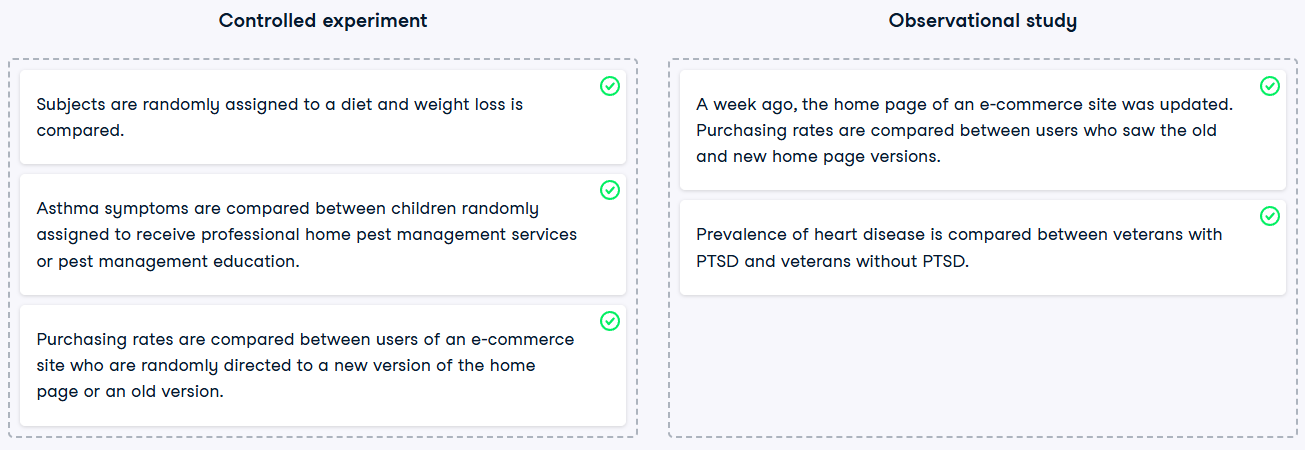

*Now that you can distinguish between controlled experiments and observational studies, you'll be able to tell when an observational study claims to esablish a causal relationship.*

**Longitudinal vs. cross-sectional studies**  
A company manufactures thermometers, and they want to study the relationship between a thermometer's age and its accuracy. To do this, they take a sample of 100 different thermometers of different ages and test how accurate they are. Is this data longitudinal or cross-sectional?

-> Cross-sectional

`this is a cross-sectional study since researchers aren't following the same set of thermometers over time and repeatedly measuring their accuracy at different ages.`